In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv("seeds_new.csv")

In [3]:
df.head()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [4]:
df.isnull().sum()

Area                       0
Perimeter                  0
Compactness                0
Length of kernel           0
Width of kernel            0
Asymmetry coefficient      0
Length of kernel groove    0
Class (1, 2, 3)            0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
print(df["Class (1, 2, 3)"].value_counts().sort_index())

Class (1, 2, 3)
1    70
2    70
3    70
Name: count, dtype: int64


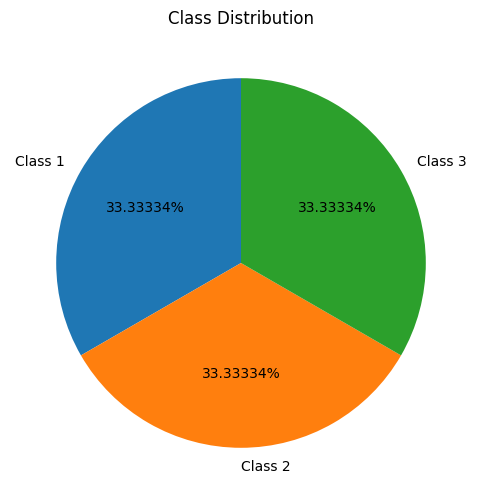

In [7]:
class_counts = df["Class (1, 2, 3)"].value_counts().sort_index()

plt.figure(figsize=(6, 6))

plt.pie(class_counts, labels=["Class 1", "Class 2", "Class 3"],autopct="%1.5f%%", startangle=90)

plt.title("Class Distribution")
plt.show()

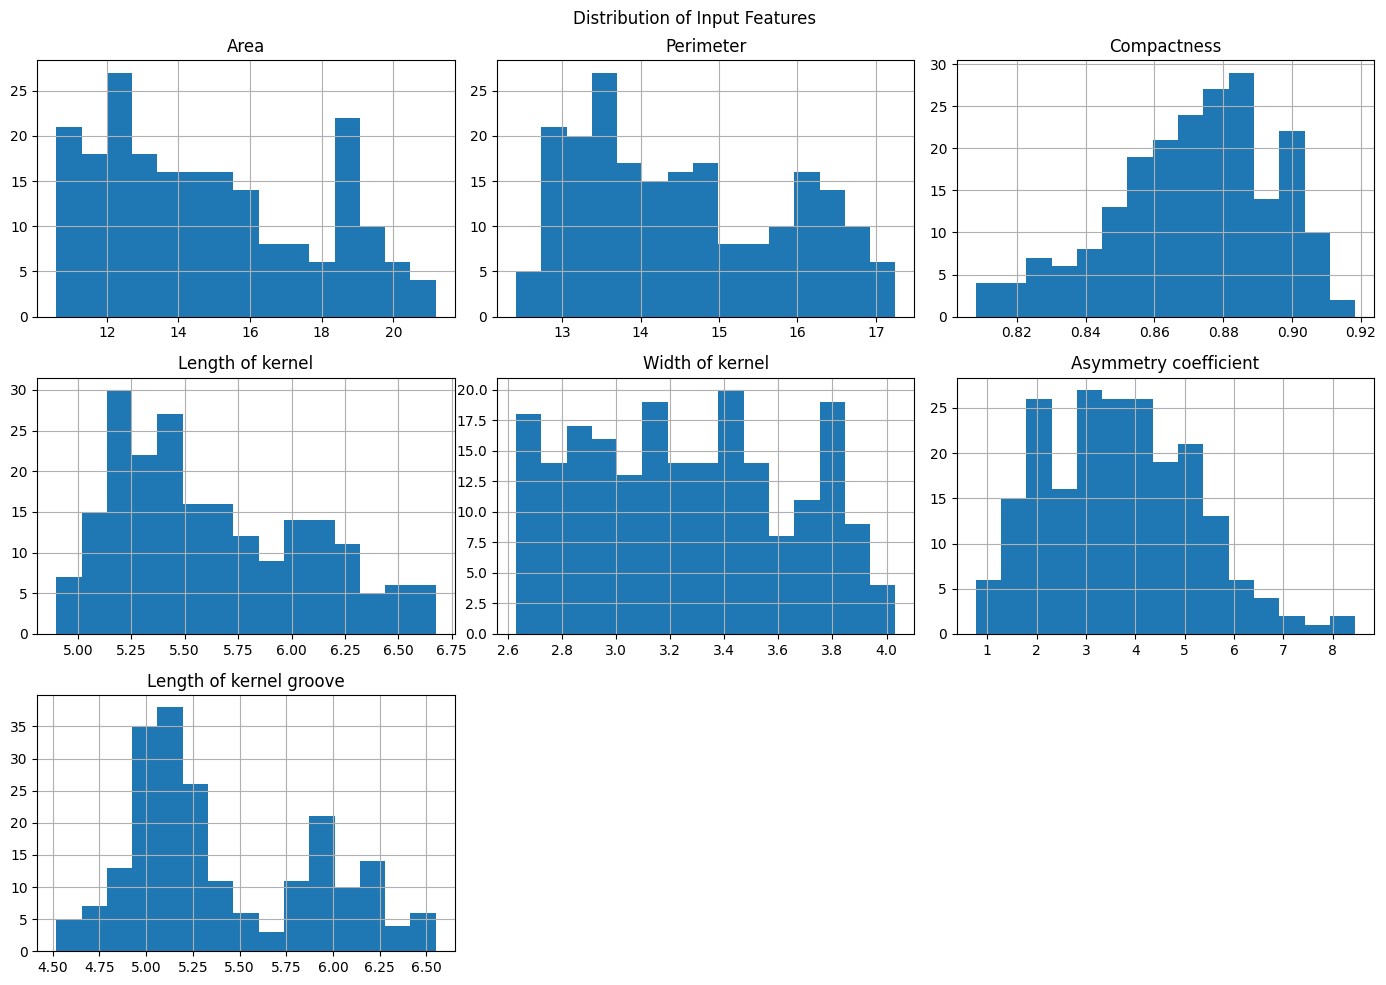

In [8]:
df.drop("Class (1, 2, 3)", axis = 1).hist(figsize = (14, 10), bins = 15)
plt.suptitle("Distribution of Input Features")
plt.tight_layout()
plt.show()

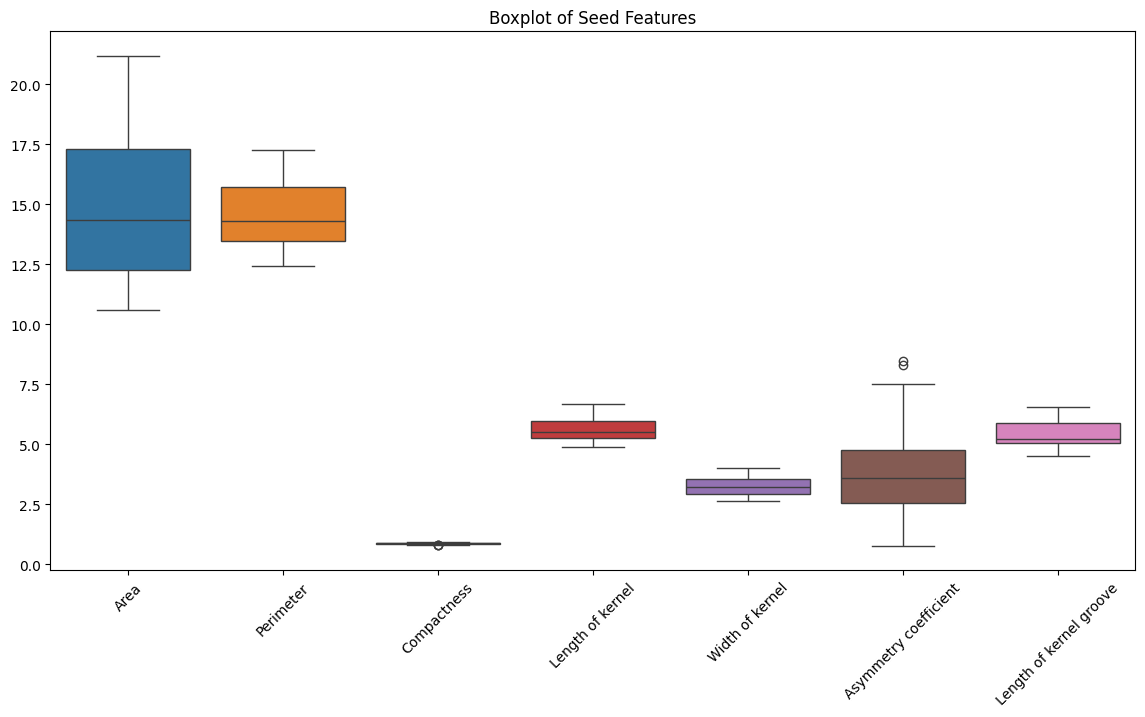

In [9]:
plt.figure(figsize = (14, 7))

sns.boxplot(data = df.drop("Class (1, 2, 3)", axis = 1))

plt.title("Boxplot of Seed Features")
plt.xticks(rotation = 45)
plt.show()

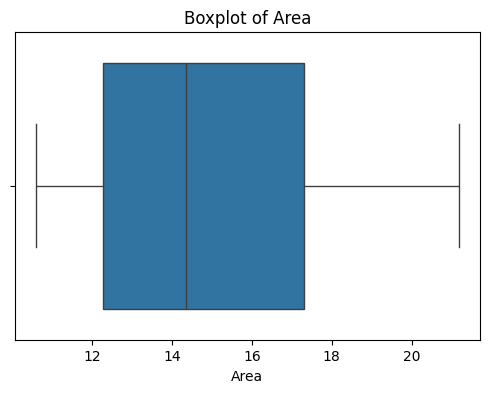

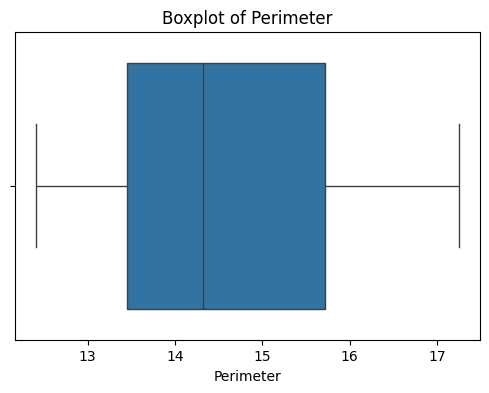

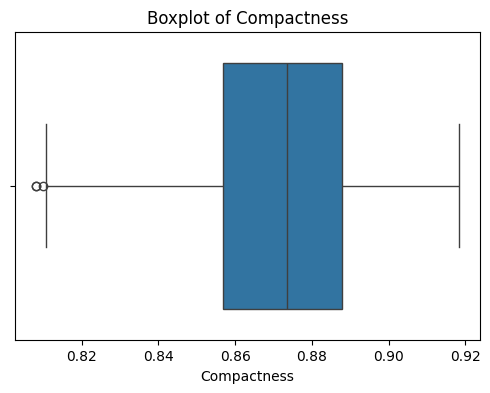

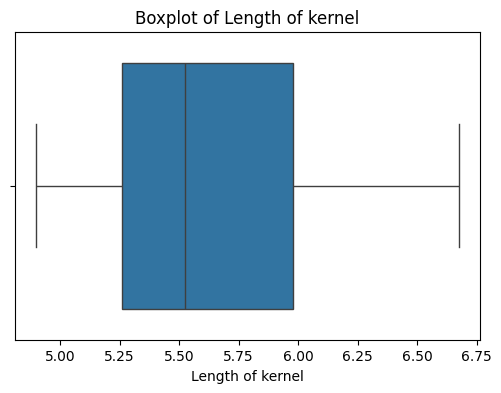

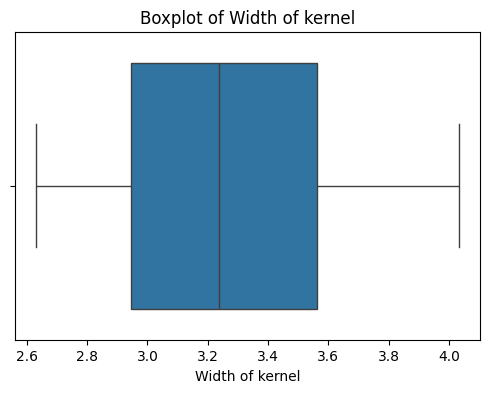

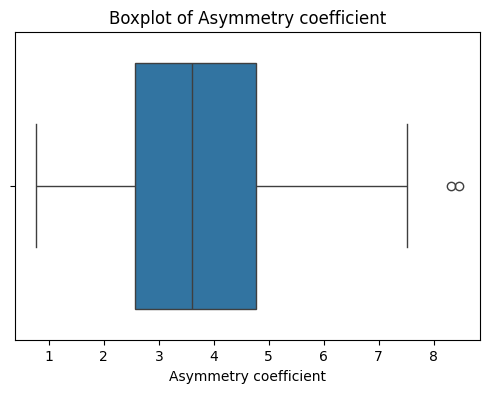

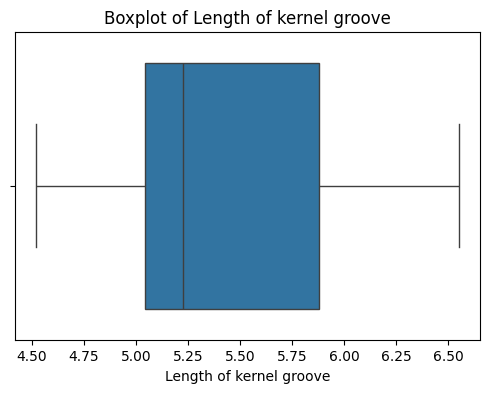

In [10]:
features = df.drop("Class (1, 2, 3)", axis = 1).columns

for feature in features:
    plt.figure(figsize=(6, 4)),sns.boxplot(x = df[feature])

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.show()

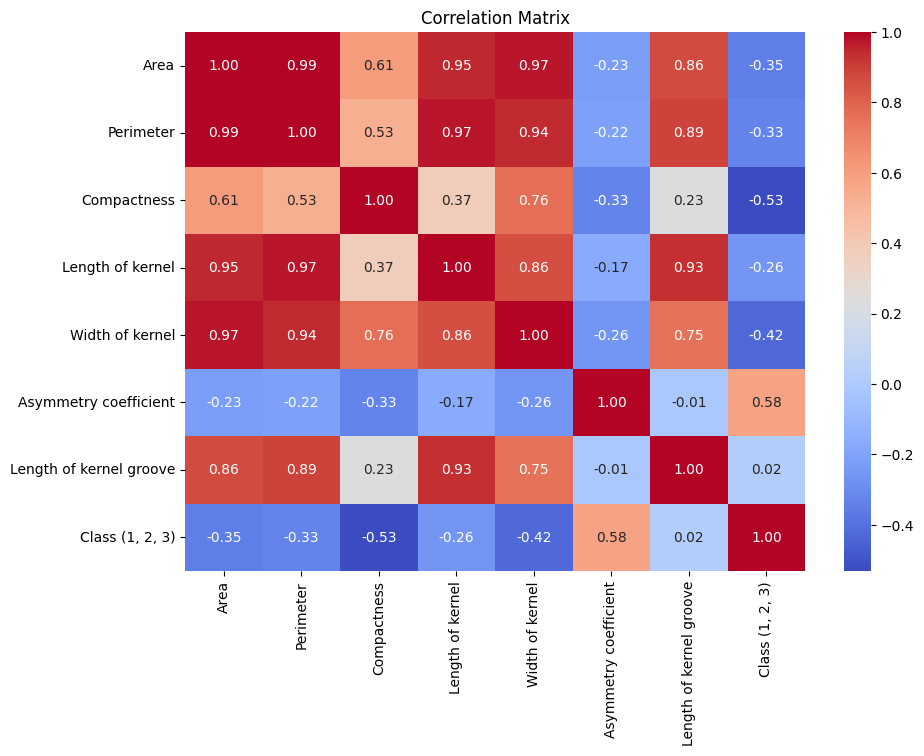

In [11]:
plt.figure(figsize=(10,7))

correlation = df.corr()

sns.heatmap(correlation,annot = True, cmap = "coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

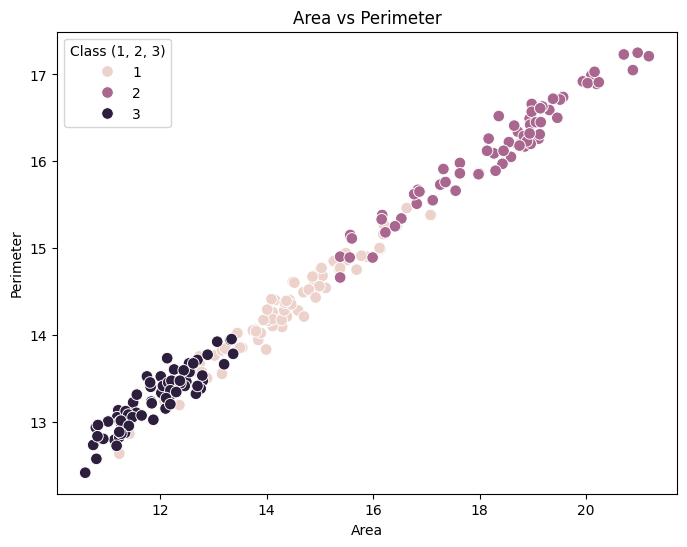

In [12]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data = df, x = "Area", y = "Perimeter", hue = "Class (1, 2, 3)", s = 70)

plt.title("Area vs Perimeter")
plt.show()

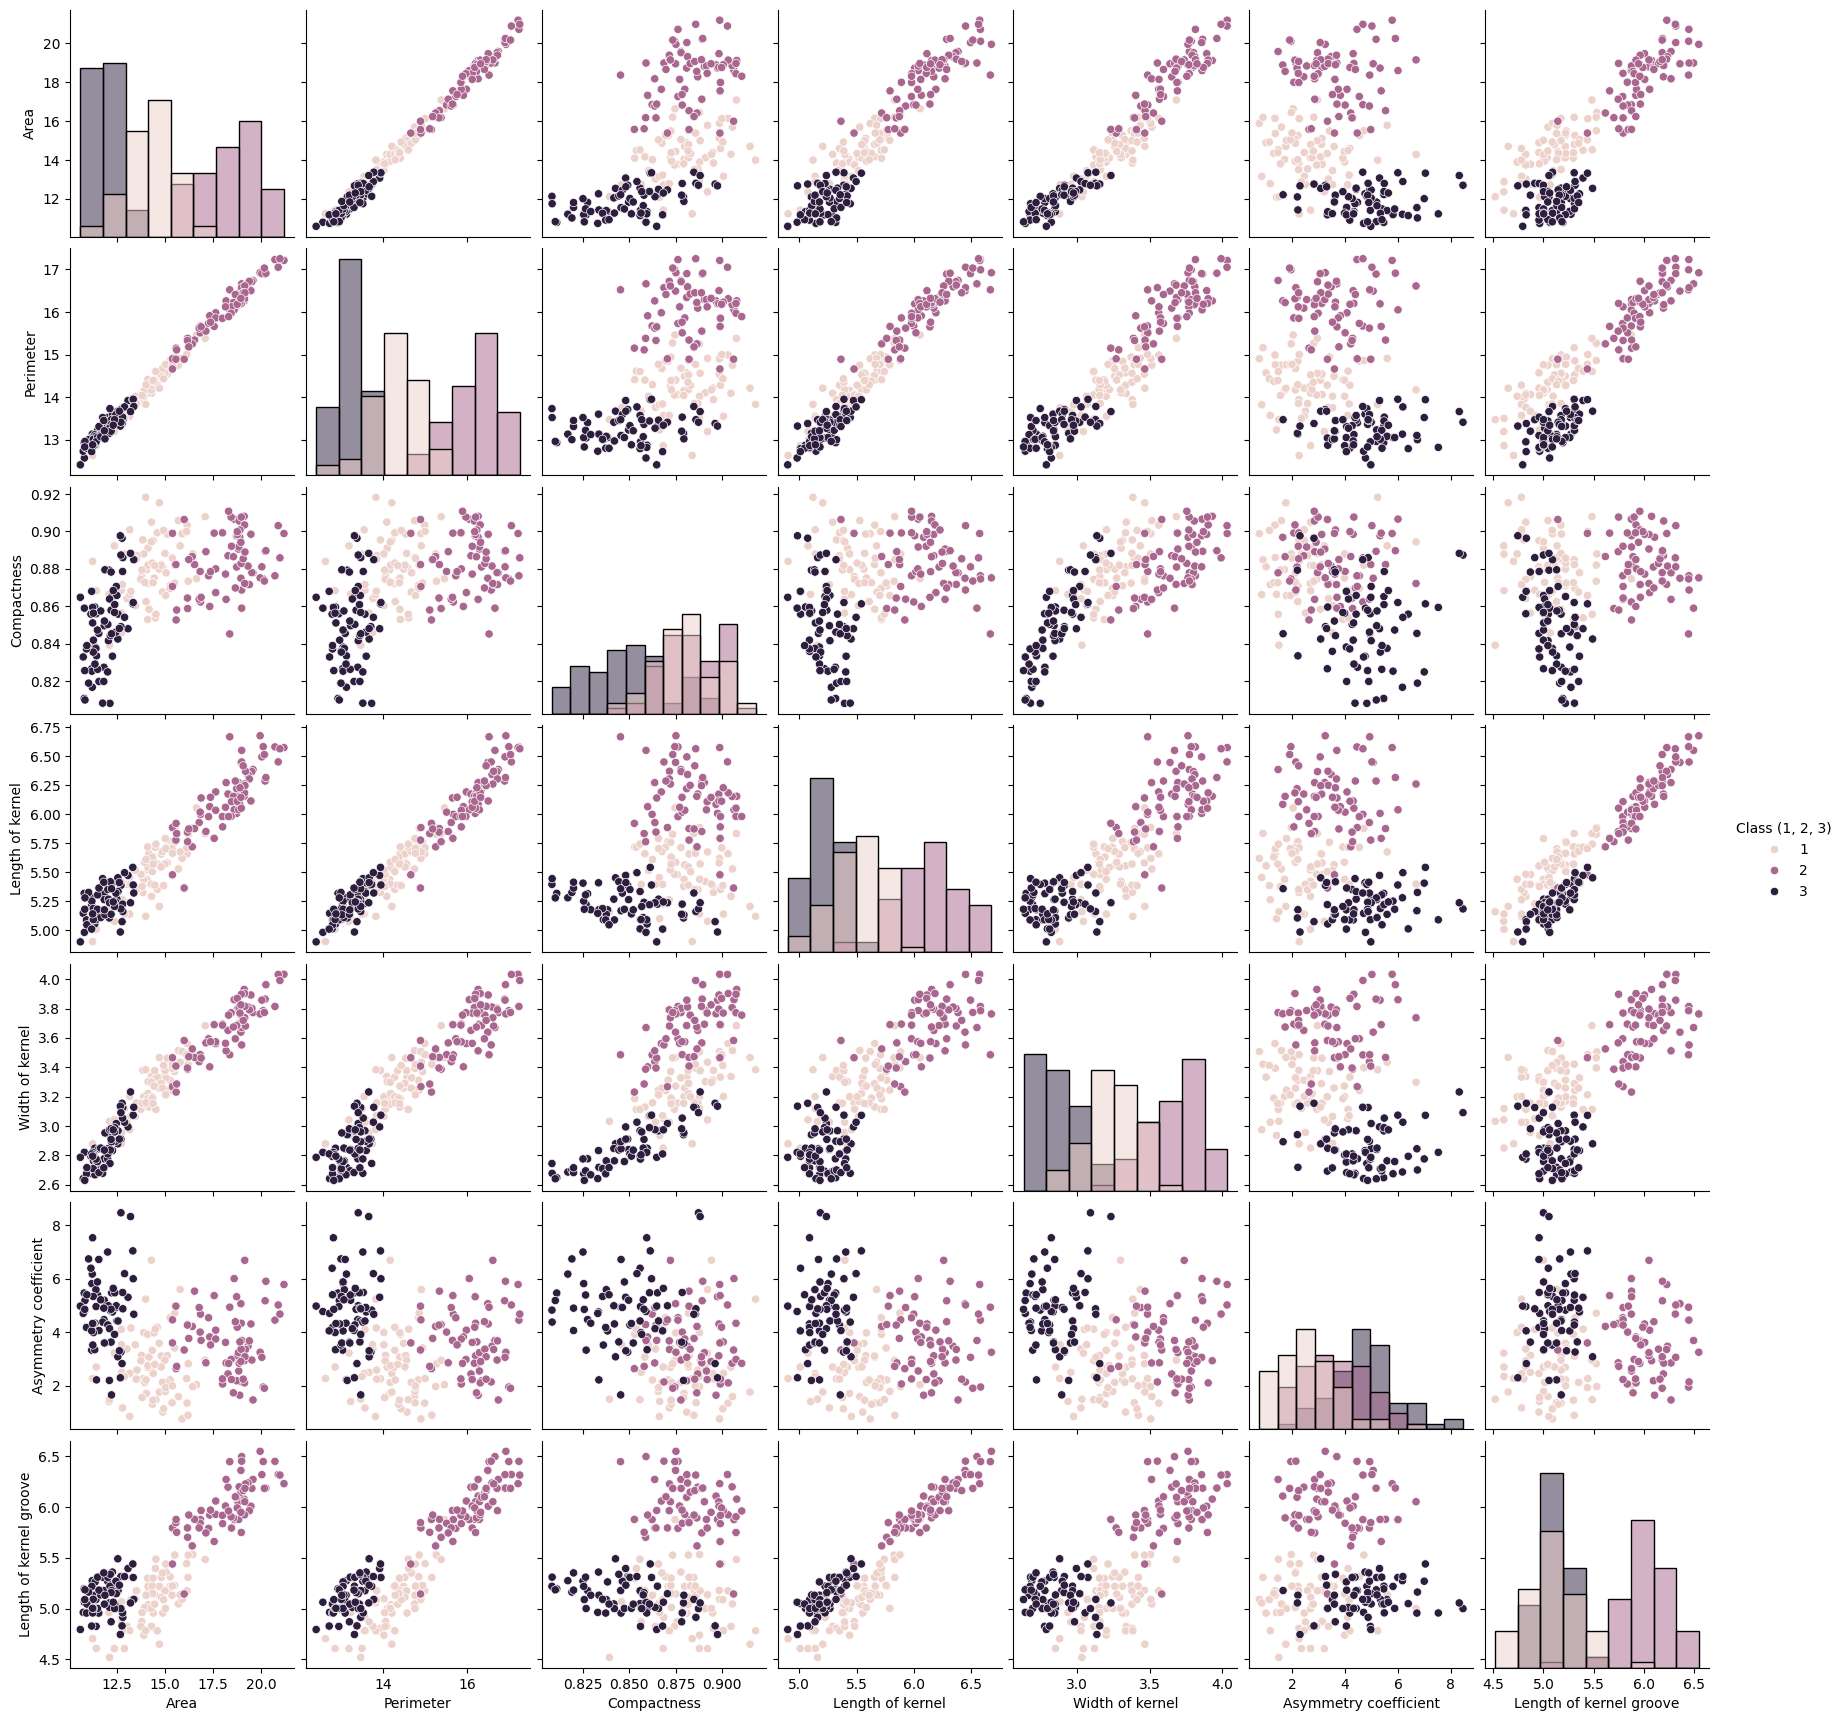

In [13]:
sns.pairplot(df, hue = "Class (1, 2, 3)", diag_kind = "hist")
plt.show()

In [14]:
X = df.drop("Class (1, 2, 3)", axis = 1)
y_original = df["Class (1, 2, 3)"]

print("Input Shape:", X.shape)
print("Target Shape:", y_original.shape)

Input Shape: (210, 7)
Target Shape: (210,)


In [15]:
y = y_original - 1

print("Original classes: ")
print(sorted(y_original.unique()))

print("\nANN encoded classes:")
print(sorted(y.unique()))

Original classes: 
[np.int64(1), np.int64(2), np.int64(3)]

ANN encoded classes:
[np.int64(0), np.int64(1), np.int64(2)]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

print("Training samples:", X_train.shape[0])
print("testing samples:", X_test.shape[0])

Training samples: 168
testing samples: 42


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [18]:
X_test_scaled = scaler.transform(X_test)

In [19]:
print("first 5 scaled training samples:")
print(X_train_scaled[:5])

first 5 scaled training samples:
[[-1.17682401 -1.1750583  -1.02169157 -1.02785725 -1.35751947  1.43188942
  -0.82441016]
 [-0.87298429 -1.06714618  0.86676795 -1.26492983 -0.59897345 -0.3056117
  -1.63150367]
 [-0.12719589  0.01968295 -0.66917913  0.25096694 -0.40933695 -1.4432301
   0.1615857 ]
 [-1.29421662 -1.37546651 -0.66498255 -1.41310019 -1.26136575  1.7668294
  -0.72886004]
 [-0.58295547 -0.70486981  0.69890488 -0.90020279 -0.09149548  3.02743357
  -0.71462918]]


In [20]:
model = Sequential([

    Input(shape = (7,)),

    Dense(16, activation = "relu"),

    Dense(8, activation = "relu"),

    Dense(3, activation = "softmax")
])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [23]:
loss = "sparse_categorical_crossentropy"

In [24]:
early_stop = EarlyStopping(monitor="val_loss", patience = 10, restore_best_weights = True)

In [25]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs = 100,
    batch_size = 16,
    validation_split = 0.20,
    callbacks = [early_stop],
    verbose = 1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2015 - loss: 1.1883 - val_accuracy: 0.1471 - val_loss: 1.2506
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2687 - loss: 1.1152 - val_accuracy: 0.1471 - val_loss: 1.1876
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3582 - loss: 1.0485 - val_accuracy: 0.2353 - val_loss: 1.1303
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4552 - loss: 0.9891 - val_accuracy: 0.2941 - val_loss: 1.0763
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5224 - loss: 0.9376 - val_accuracy: 0.3529 - val_loss: 1.0247
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5597 - loss: 0.8906 - val_accuracy: 0.3235 - val_loss: 0.9779
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5970 - loss: 0.8475 - val_accuracy: 0.4118 - val_loss: 0.9347
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5970 - loss: 0.8093 - val_accuracy: 0.4118 - val_loss: 0.8921

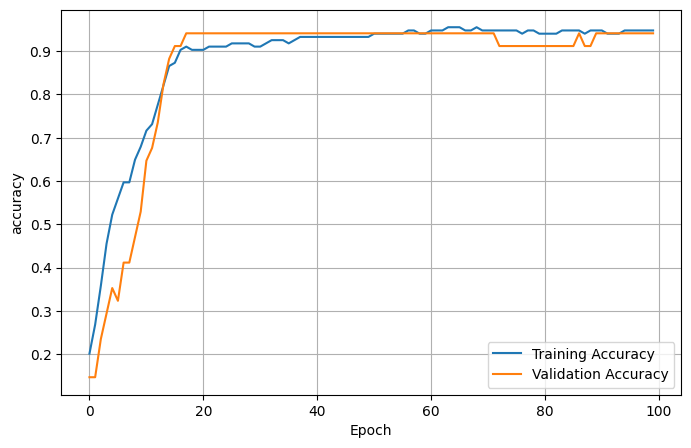

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"],label = "Training Accuracy")

plt.plot(history.history["val_accuracy"],label = "Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)

plt.show()

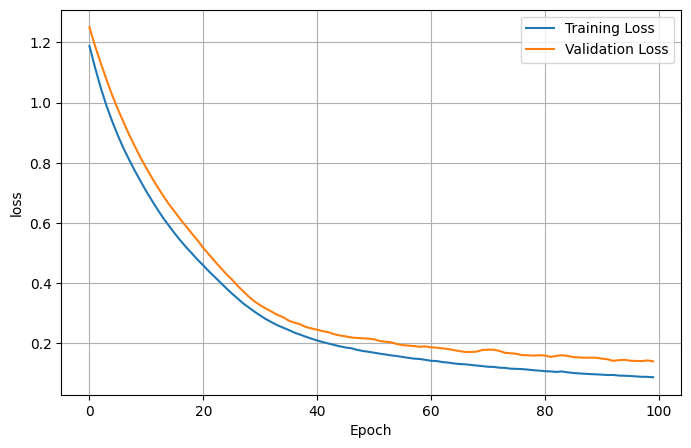

In [27]:
####
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"],label = "Training Loss")

plt.plot(history.history["val_loss"],label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose = 1)

print("Test Loss", test_loss)
print("Test Accuracy", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8333 - loss: 0.3314
Test Loss 0.33144617080688477
Test Accuracy 0.8333333134651184


In [29]:
y_prob = model.predict(X_test_scaled, verbose = 1)

print(y_prob[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[9.9604529e-01 5.5254024e-04 3.4021498e-03]
 [5.4047145e-02 7.4712432e-04 9.4520569e-01]
 [6.2689447e-01 3.4856567e-01 2.4539819e-02]
 [1.8120978e-03 9.1557004e-06 9.9817872e-01]
 [2.2929404e-03 9.9770689e-01 1.1390393e-07]]


In [30]:
y_pred = np.argmax(y_prob, axis = 1)

print("Predicted encoded classes:")
print(y_pred[:10])

Predicted encoded classes:
[0 2 0 2 1 2 1 1 1 1]


In [31]:
y_pred_original = y_pred + 1
y_test_original = y_test + 1

print("Predicted classes:")
print(y_pred_original[:10])

Predicted classes:
[1 3 1 3 2 3 2 2 2 2]


In [32]:
comparison = pd.DataFrame({
    "Actual Class": y_test_original.values,
    "Predicted Class": y_pred_original
})

comparison.head(15)

,Actual Class,Predicted Class
0,1,1
1,3,3
2,2,1
3,3,3
4,2,2
5,3,3
6,2,2
7,1,2
8,2,2
9,2,2


In [33]:
accuracy = accuracy_score(y_test_original, y_pred_original)
print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


In [34]:
precision = precision_score(y_test_original, y_pred_original, average="weighted")
print("Precision:", precision)

Precision: 0.8416394335511983


In [35]:
recall = recall_score(y_test_original, y_pred_original, average="weighted")
print("Recall:", recall)

Recall: 0.8333333333333334


In [36]:
f1 = f1_score(y_test_original, y_pred_original, average="weighted")
print("F1 Score:", f1)

F1 Score: 0.8218482156771078


In [37]:
print(classification_report(y_test_original, y_pred_original))

              precision    recall  f1-score   support

           1       0.89      0.57      0.70        14
           2       0.81      0.93      0.87        14
           3       0.82      1.00      0.90        14

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.82        42
weighted avg       0.84      0.83      0.82        42



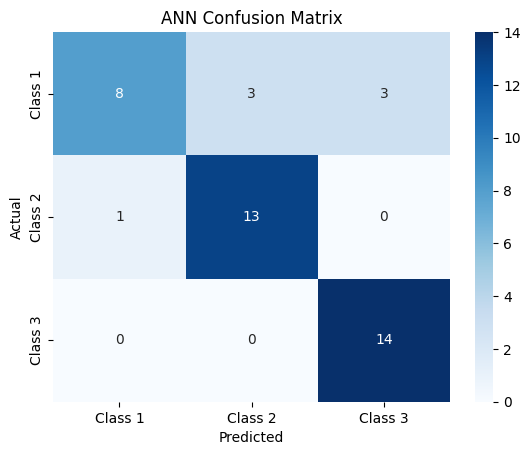

In [38]:
cm = confusion_matrix(y_test_original, y_pred_original)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 1','Class 2','Class 3'],
            yticklabels=['Class 1','Class 2','Class 3'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN Confusion Matrix')
plt.show()